In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection
import stim

import os 

while 'honeycomb.py' not in os.listdir():
    os.chdir("..")

from honeycomb import CSSHoneycomb

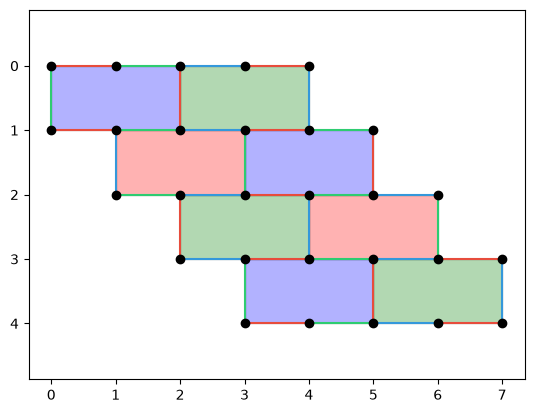

In [2]:
honey = CSSHoneycomb(5, 5)
honey.plot_surface()

In [3]:
plaquettes = honey.plaquettes
p1 = [p for p in plaquettes if len(p) == 1]
print(p1)

[]


# data qubits
QUBIT_COORDS(0,0) 0
QUBIT_COORDS(1,0) 1
QUBIT_COORDS(2,0) 2
QUBIT_COORDS(3,0) 3
QUBIT_COORDS(4,0) 4
QUBIT_COORDS(0,1) 5
QUBIT_COORDS(1,1) 6
QUBIT_COORDS(2,1) 7
QUBIT_COORDS(3,1) 8
QUBIT_COORDS(4,1) 9
QUBIT_COORDS(5,1) 10
QUBIT_COORDS(1,2) 11
QUBIT_COORDS(2,2) 12
QUBIT_COORDS(3,2) 13
QUBIT_COORDS(4,2) 14
QUBIT_COORDS(5,2) 15
QUBIT_COORDS(6,2) 16
QUBIT_COORDS(2,3) 17
QUBIT_COORDS(3,3) 18
QUBIT_COORDS(4,3) 19
QUBIT_COORDS(5,3) 20
QUBIT_COORDS(6,3) 21
QUBIT_COORDS(7,3) 22
QUBIT_COORDS(3,4) 23
QUBIT_COORDS(4,4) 24
QUBIT_COORDS(5,4) 25
QUBIT_COORDS(6,4) 26
QUBIT_COORDS(7,4) 27
# ancilla qubits
QUBIT_COORDS(0.0,0.5) 28
QUBIT_COORDS(0.5,0.0) 29
QUBIT_COORDS(1.5,0.0) 30
QUBIT_COORDS(2.0,0.5) 31
QUBIT_COORDS(2.5,0.0) 32
QUBIT_COORDS(3.5,0.0) 33
QUBIT_COORDS(4.0,0.5) 34
QUBIT_COORDS(0.5,1.0) 35
QUBIT_COORDS(1.0,1.5) 36
QUBIT_COORDS(1.5,1.0) 37
QUBIT_COORDS(2.5,1.0) 38
QUBIT_COORDS(3.0,1.5) 39
QUBIT_COORDS(3.5,1.0) 40
QUBIT_COORDS(4.5,1.0) 41
QUBIT_COORDS(5.0,1.5) 42
QUBIT_COORDS(1.5

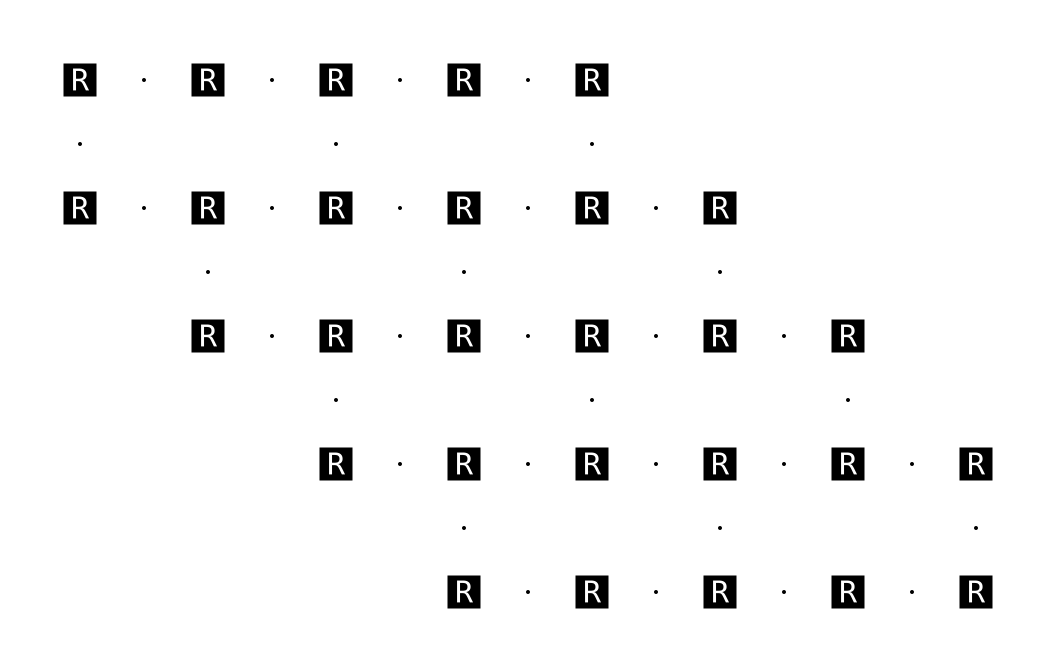

In [4]:
string = honey.initialise_circuit(coordinates='square')
string += honey.prepare_qubits()
print(string)
circuit = stim.Circuit(string)
circuit.diagram("detslice-with-ops-svg")

In [5]:
# TODO do we use letters or words?
COLOUR_MAP = {
    'r' : 'red',
    'g' : 'green',
    'b' : 'blue'
}

def measurement_cycle(honey: CSSHoneycomb, cycle=["rZ", "gX", "bZ", "rX", "gZ", "bX"]):
    """
    measure our stabilizers
    """

    string = ""
    for m in cycle:
        colour = COLOUR_MAP[m[0]]
        flavour = m[1]

        string += f"#{colour}{flavour}\n"
        string += honey.measure_edges(colour, flavour) + "\n"
        string += "tick\n"
    
    return string

print(measurement_cycle(honey, ['rXX', 'gZZ']))

#redX
# prepare ancillas in X basis
R 29 31 33 35 40 42 44 46 53 55 57 59 62 
TICK
H 29 31 33 35 40 42 44 46 53 55 57 59 62 
TICK
# fold stabilizers
CNOT 0 29 2 31 3 33 5 35 8 40 10 42 12 44 13 46 18 53 20 55 21 57 23 59 26 62 
TICK
CNOT 1 29 7 31 4 33 6 35 9 40 15 42 17 44 14 46 19 53 25 55 22 57 24 59 27 62 
TICK
# rotate ancillas back to Z basis
H 29 31 33 35 40 42 44 46 53 55 57 59 62 
TICK
M 29 31 33 35 40 42 44 46 53 55 57 59 62 
tick
#greenZ
# prepare ancillas in Z basis
R 28 30 37 39 41 43 48 50 52 54 60 
TICK
# fold stabilizers
CNOT 28 0 30 1 37 6 39 8 41 9 43 11 48 14 50 16 52 18 54 19 60 24 
TICK
CNOT 28 5 30 2 37 7 39 13 41 10 43 12 48 15 50 21 52 23 54 20 60 25 
TICK
M 28 30 37 39 41 43 48 50 52 54 60 
tick



A full cycle looks like:

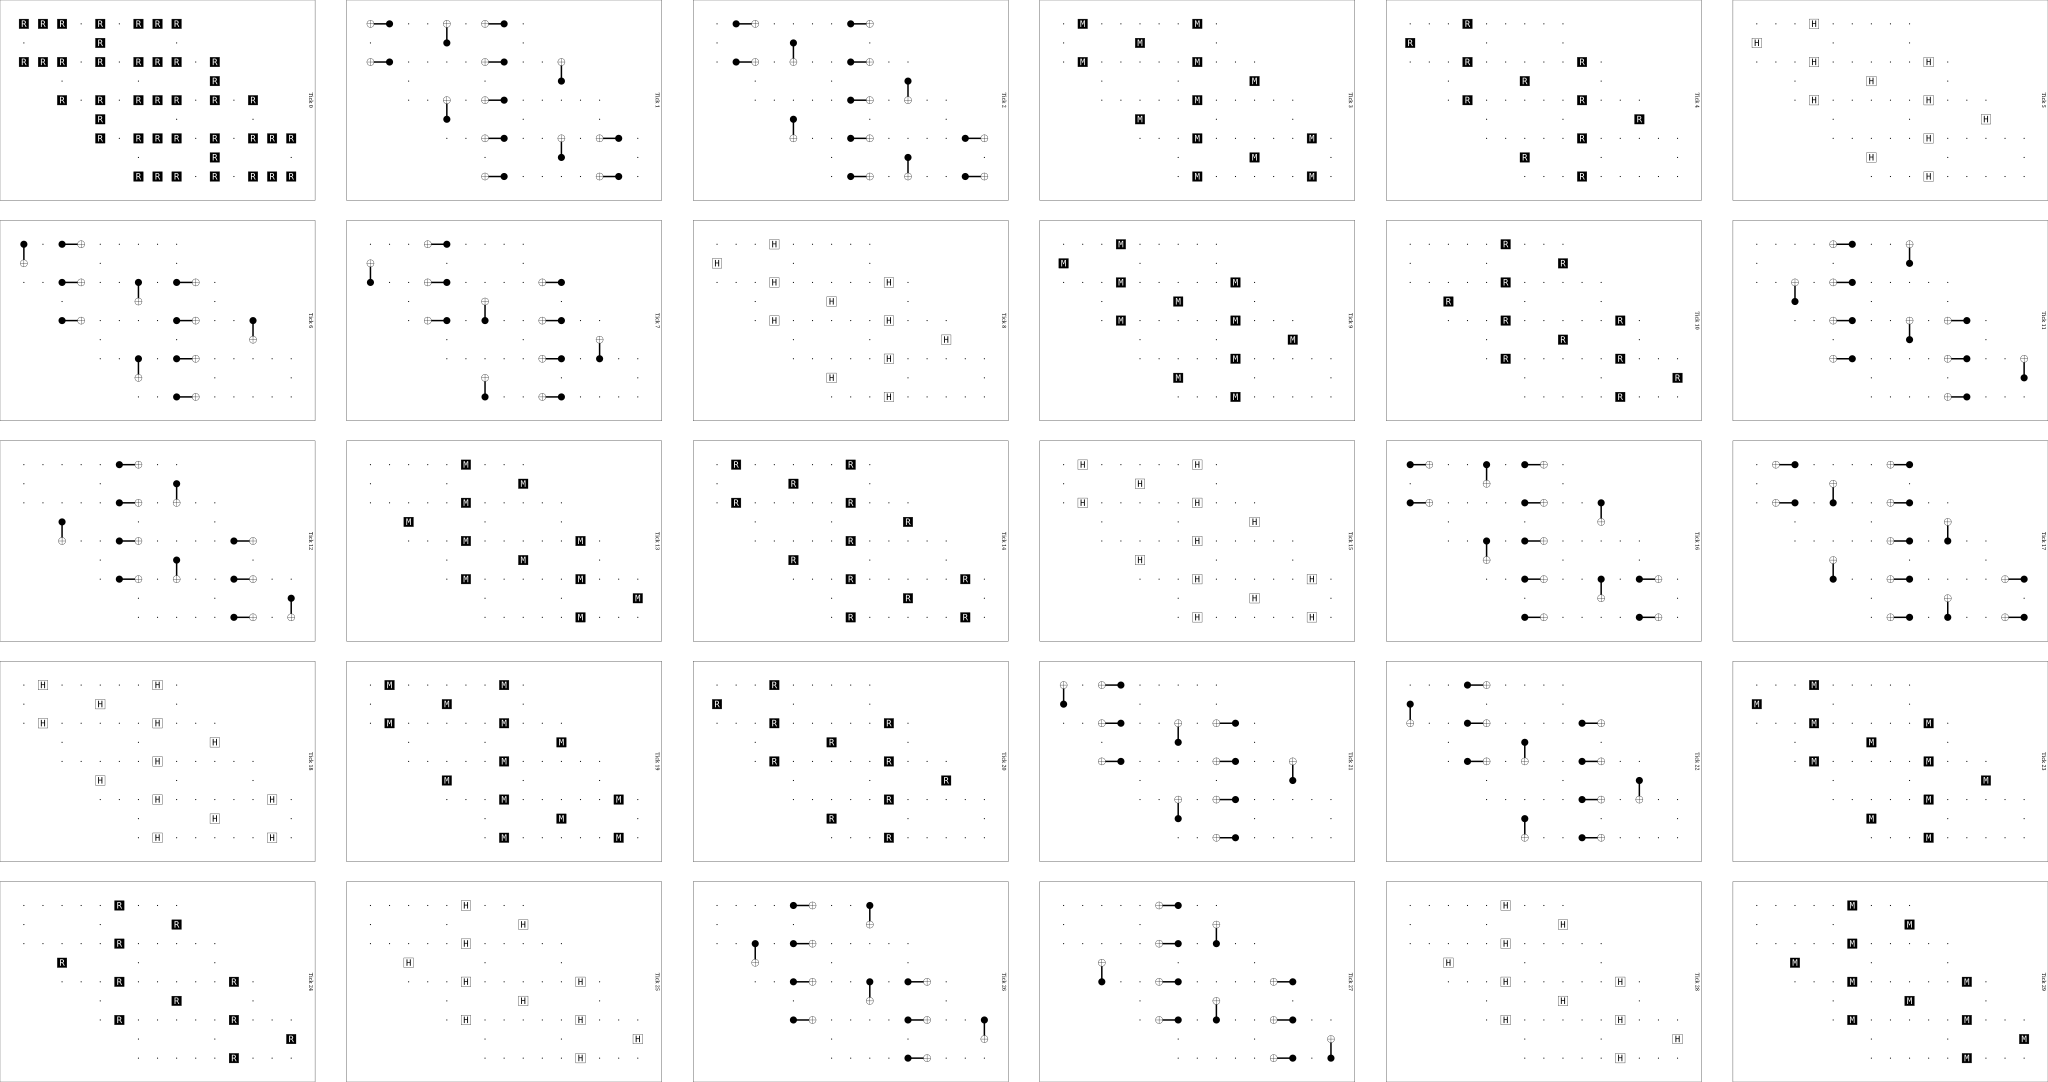

In [6]:
string = measurement_cycle(honey)
# print(string)
c_meas = stim.Circuit(string)
circuit += c_meas

circuit.diagram("timeslice-svg")

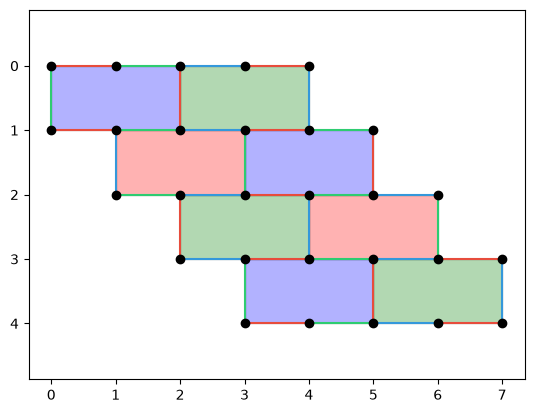

In [9]:
honey.plot_surface()